In [1]:
SEED = 24520789


In [2]:
# Reproducibility enforcement and quick seed check
import os, random, numpy as np, torch

# Ensure Python hash seed is stable for reproducible hashing behavior
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Prefer deterministic algorithms where possible (can reduce throughput)
try:
    torch.use_deterministic_algorithms(False)
    print('torch.use_deterministic_algorithms(False) enabled')
except Exception as e:
    print('Could not enable torch.use_deterministic_algorithms:', e)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    print('Falling back to cudnn deterministic mode')

# Quick seed check: sample twice after reseeding and compare

def _sample_once():
    return {
        'py_random': [random.random() for _ in range(3)],
        'np_rand': np.random.rand(3).tolist(),
        'torch_cpu': torch.rand(3).tolist(),
    }

a = _sample_once()
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
b = _sample_once()
print('Seed check match:', a == b)
print('Sample (1):', a)
print('Sample (2):', b)


torch.use_deterministic_algorithms(False) enabled
Seed check match: True
Sample (1): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}
Sample (2): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}


# HaGRID 5-Class Object Detection (PyTorch From Scratch)

This notebook does the following:
1. Downloads HaGRID from Kaggle.
2. Builds and trains custom object detection models from scratch in PyTorch.
3. Compares model quality and speed (accuracy, precision, recall, IoU, and latency in ms).

Target classes in this notebook:
- `one` (gesture 1)
- `peace` (gesture 2)
- `three` (gesture 3)
- `four` (gesture 4)
- `fist`


In [3]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from pathlib import Path
from collections import Counter
import importlib.util

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
try:
    import torchmetrics
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics"])
    import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import classification_report, confusion_matrix

# --- ENVIRONMENT-AWARE PATHS ---
def get_environment() -> str:
    if os.getenv('KAGGLE_DATA_FOLDER') or Path('/kaggle/input').exists():
        return 'kaggle'
    if importlib.util.find_spec('google.colab') is not None:
        return 'colab'
    return 'local'

ENVIRONMENT = get_environment()

if ENVIRONMENT == 'kaggle':
    DATASET_ROOT = Path('/kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p')
    MODEL_DIR = Path('/kaggle/working/models')
elif ENVIRONMENT == 'colab':
    DATASET_ROOT = Path('/content/hagrid_dataset/hagrid-sample-30k-384p')
    MODEL_DIR = Path('/content/models')
else:
    REPO_ROOT = Path('.').resolve()
    DATASET_ROOT = REPO_ROOT / 'data' / 'hagrid-sample-30k-384p-5class'
    MODEL_DIR = REPO_ROOT / 'models'

EXTRACT_DIR = DATASET_ROOT
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment: {ENVIRONMENT}')
print(f'Dataset root: {DATASET_ROOT}')
print(f'Model dir: {MODEL_DIR}')

KEEP_CLASSES = ['one', 'peace', 'three', 'four', 'fist']
TARGET_CLASSES = KEEP_CLASSES
CLASS_TO_ID = {c: i for i, c in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


Environment: kaggle
Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Model dir: /kaggle/working/models


In [4]:
def build_filename_index(img_root: Path, class_names=None):
    img_root = Path(img_root)
    index = {}
    if not img_root.exists():
        return index

    if class_names:
        candidate_dirs = [img_root / f"train_val_{class_name}" for class_name in class_names]
        candidate_dirs = [d for d in candidate_dirs if d.exists()]
    else:
        candidate_dirs = [img_root]

    for root_dir in candidate_dirs:
        for p in root_dir.rglob("*"):
            if p.suffix.lower() in IMG_EXTS and p.is_file():
                stem = p.stem
                name = p.name
                index.setdefault(stem, p)
                index.setdefault(name, p)
                try:
                    rel = str(p.relative_to(img_root))
                    index.setdefault(rel, p)
                except Exception:
                    pass
    return index


def resolve_image_path(filename_index: dict, image_key: str):
    if image_key is None:
        return None
    key = str(image_key)
    if key in filename_index:
        return filename_index[key]
    for ext in IMG_EXTS:
        if (key + ext) in filename_index:
            return filename_index[key + ext]
    stem = Path(key).stem
    if stem in filename_index:
        return filename_index[stem]
    return None


def xywh_to_xyxy(box, w: int, h: int, normalized: bool = True, xywh_mode: str = "topleft"):
    x, y, bw, bh = box[:4]
    if normalized:
        x = float(x) * w
        y = float(y) * h
        bw = float(bw) * w
        bh = float(bh) * h

    if xywh_mode == "center":
        x1 = float(x - bw / 2.0)
        y1 = float(y - bh / 2.0)
        x2 = float(x + bw / 2.0)
        y2 = float(y + bh / 2.0)
    else:
        # HaGRID bboxes are top-left xywh in this project dataset.
        x1 = float(x)
        y1 = float(y)
        x2 = float(x + bw)
        y2 = float(y + bh)

    x1 = max(0.0, min(x1, w))
    y1 = max(0.0, min(y1, h))
    x2 = max(0.0, min(x2, w))
    y2 = max(0.0, min(y2, h))
    return x1, y1, x2, y2


In [5]:
import os
import json
import time
import random
import shutil
import subprocess
import hashlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import torchmetrics
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics"])
    import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import classification_report, confusion_matrix

# SEED = 42 # Removed original seed definition
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Also set CUDA seeds for reproducibility on GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

REPO_ROOT = Path(".").resolve()
DATA_ROOT = REPO_ROOT / "data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
REGISTRY_PATH = REPO_ROOT / "dataset_registry.json"


def load_registry(path: Path):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            pass
    return {"datasets": {}}


def save_registry(path: Path, registry: dict):
    path.write_text(json.dumps(registry, indent=2), encoding="utf-8")


def sha1_of_file(path: Path):
    if not path.exists():
        return None
    h = hashlib.sha1()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def ensure_kaggle_installed():
    try:
        import kaggle  # noqa: F401
        print("kaggle package already available in notebook kernel")
    except Exception:
        print("Installing kaggle package in notebook kernel...")
        subprocess.check_call(["python", "-m", "pip", "install", "-q", "kaggle"])
        import kaggle  # noqa: F401
        print("kaggle package installed")


Device: cuda


## 1) One-Time Kaggle Setup + Filtered 5-Class Dataset

This section does all of this:
- Uses the Kaggle token file from `C:/Users/<you>/.kaggle/access_token.txt`.
- Detects if the filtered HaGRID Sample 30k 384p 5-class dataset is already present in this repo.
- Builds a repo-local filtered copy that keeps only the five train classes: `one`, `peace`, `three`, `four`, `fist`.
- Stores dataset metadata in `dataset_registry.json` at repo root.
- Verifies the reduced dataset afterward by counting only the kept image folders and annotation JSONs.

Dataset reference: `innominate817/hagrid-sample-30k-384p`.

Important:
- The notebook now uses the filtered 5-class copy stored at `data/hagrid-sample-30k-384p-5class`.
- The later parsing/training cells work with that filtered dataset root.


In [6]:
# Align downstream cells with the dataset prepared in cell 2.
EXTRACT_DIR = DATASET_ROOT
print("Using dataset root:", EXTRACT_DIR)
print("JSON files:", len(list(EXTRACT_DIR.rglob("*.json"))))
print("Image files:", len(list(EXTRACT_DIR.rglob("*.jpg"))))


Using dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
JSON files: 18
Image files: 31833


In [7]:
def parse_hagrid_like_annotations(dataset_root: Path, target_classes):
    """Parse the exact HaGRID 5-class repo layout into flat training records.

    The dataset layout is:
    - ann_train_val/{class}.json
    - hagrid_30k/train_val_{class}/<image_id>.jpg

    Each JSON is a dict keyed by image id, and each value contains:
    - bboxes: list[[x, y, w, h]] (top-left xywh)
    - labels: list[str]
    - user_id: str (for better data splitting)
    """
    ann_dir = dataset_root / "ann_train_val"
    img_root = dataset_root / "hagrid_30k"
    json_files = [ann_dir / f"{class_name}.json" for class_name in target_classes]

    print(f"Found {len(json_files)} annotation files")
    print("Building filename index for target classes only...")
    filename_index = build_filename_index(img_root, target_classes)
    print(f"Indexed {len(filename_index)} image-name entries")

    records = []
    image_size_cache = {}
    t_start = time.perf_counter()
    t_last_report = t_start
    skipped_missing_image = 0
    skipped_bad_json = 0
    total_images_seen = 0

    for jf in tqdm(json_files, desc="Parsing annotations"):
        if not jf.exists():
            continue
        try:
            data = json.loads(jf.read_text(encoding="utf-8"))
        except Exception:
            skipped_bad_json += 1
            continue

        if not isinstance(data, dict):
            skipped_bad_json += 1
            continue

        for image_key, item in data.items():
            if not isinstance(item, dict):
                continue

            labels = item.get("labels") or []
            bboxes = item.get("bboxes") or []
            if not labels or not bboxes:
                continue

            total_images_seen += 1
            img_path = resolve_image_path(filename_index, image_key)
            if img_path is None:
                skipped_missing_image += 1
                continue

            try:
                if img_path in image_size_cache:
                    w, h = image_size_cache[img_path]
                else:
                    # Read only image headers for size; avoid full decode during parsing.
                    with Image.open(img_path) as img_pil:
                        w, h = img_pil.size
                    image_size_cache[img_path] = (w, h)
            except Exception:
                continue

            # ADDED: Capture user_id for better data splitting
            user_id = item.get("user_id", "unknown")

            for label, box in zip(labels, bboxes):
                if label not in target_classes:
                    continue
                if not isinstance(box, (list, tuple)) or len(box) < 4:
                    continue
                normalized = max(box[:4]) <= 1.5
                x1, y1, x2, y2 = xywh_to_xyxy(box[:4], w, h, normalized=normalized, xywh_mode="topleft")
                records.append({
                    "image_path": str(img_path),
                    "bbox_xyxy": [x1, y1, x2, y2],
                    "class_id": CLASS_TO_ID[label],
                    "user_id": user_id,  # ADDED: user_id for splitting
                })

            if len(records) % 5000 == 0 and len(records) > 0:
                now = time.perf_counter()
                elapsed = now - t_start
                since_last = now - t_last_report
                t_last_report = now
                print(f"  Parsed {len(records):,} records from {total_images_seen:,} images in {elapsed:.1f}s (+{since_last:.1f}s)")

    total_elapsed = time.perf_counter() - t_start
    print(f"Skipped missing-image records: {skipped_missing_image}")
    print(f"Skipped unreadable JSON files: {skipped_bad_json}")
    print(f"  Unique images cached: {len(image_size_cache)}")
    print(f"  Total image keys visited: {total_images_seen}")
    print(f"  Total parse time: {total_elapsed:.1f}s")
    return records


records = parse_hagrid_like_annotations(EXTRACT_DIR, TARGET_CLASSES)
print("Parsed records (raw):", len(records))
# Filter to single-hand images only (images that appear exactly once)
img_counts = Counter(r['image_path'] for r in records)
single_records = [r for r in records if img_counts[r['image_path']] == 1]
print(f"Records before filter: {len(records)}, after filter (single-hand only): {len(single_records)}")
records = single_records
if len(records) == 0:
    print("No samples parsed after single-hand filtering. Check dataset structure and annotation schema.")


Found 5 annotation files
Building filename index for target classes only...
Indexed 26514 image-name entries


Parsing annotations:   0%|          | 0/5 [00:00<?, ?it/s]

  Parsed 5,000 records from 79,945 images in 26.4s (+26.4s)
Skipped missing-image records: 132568
Skipped unreadable JSON files: 0
  Unique images cached: 8838
  Total image keys visited: 141406
  Total parse time: 45.6s
Parsed records (raw): 8837
Records before filter: 8837, after filter (single-hand only): 8837


Checking if records have user_id field...
Split by user ID: 2410 train users, 516 val users, 517 test users
Train: 6298, Val: 1278, Test: 1261


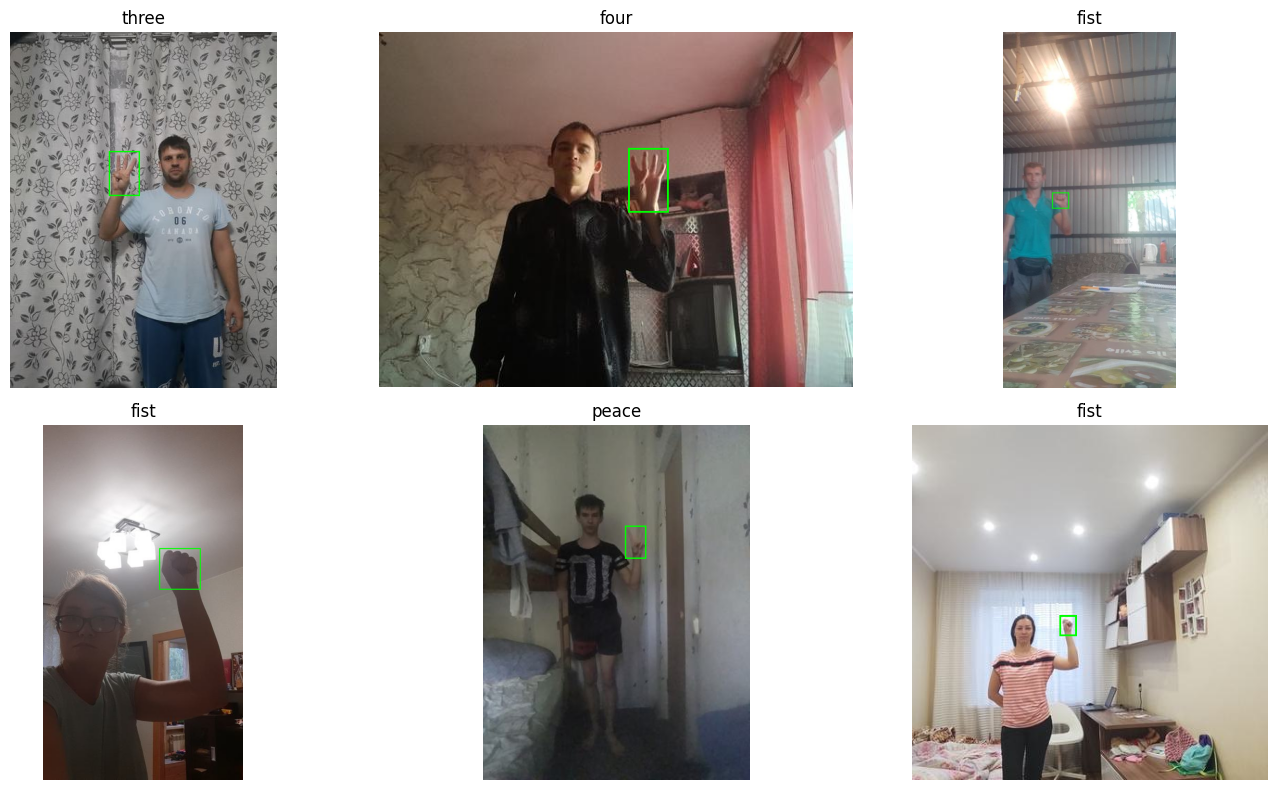

In [8]:
# Use the exact filtered 5-class dataset already prepared in the repo.
# Split by user_id to avoid data leakage (no user should appear in multiple splits)
print("Checking if records have user_id field...")
has_user_id = any('user_id' in r for r in records)

if has_user_id:
    # User-based splitting
    unique_users = list(set([r.get('user_id', 'unknown') for r in records]))
    random.shuffle(unique_users)
    n_users = len(unique_users)
    n_train_users = int(0.7 * n_users)
    n_val_users = int(0.15 * n_users)
    
    train_users = set(unique_users[:n_train_users])
    val_users = set(unique_users[n_train_users:n_train_users + n_val_users])
    test_users = set(unique_users[n_train_users + n_val_users:])
    
    train_records = [r for r in records if r.get('user_id', 'unknown') in train_users]
    val_records = [r for r in records if r.get('user_id', 'unknown') in val_users]
    test_records = [r for r in records if r.get('user_id', 'unknown') in test_users]
    
    print(f"Split by user ID: {len(train_users)} train users, {len(val_users)} val users, {len(test_users)} test users")
else:
    # Fallback to random shuffling if user_id not available (legacy dataset)
    print("WARNING: user_id not available in records. Using random splitting (potential data leakage).")
    random.shuffle(records)
    
    n = len(records)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    
    train_records = records[:n_train]
    val_records = records[n_train:n_train + n_val]
    test_records = records[n_train + n_val:]

print(f"Train: {len(train_records)}, Val: {len(val_records)}, Test: {len(test_records)}")


def draw_box(image, box, color, width=2):
    draw = ImageDraw.Draw(image)
    for offset in range(width):
        draw.rectangle(
            [box[0] - offset, box[1] - offset, box[2] + offset, box[3] + offset],
            outline=color,
        )


def show_samples(samples, n_show=6):
    if len(samples) == 0:
        print("No samples to show")
        return
    idxs = np.random.choice(len(samples), size=min(n_show, len(samples)), replace=False)
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs, 1):
        s = samples[idx]
        with Image.open(s["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
        x1, y1, x2, y2 = map(int, s["bbox_xyxy"])
        draw_box(img, (x1, y1, x2, y2), color=(0, 255, 0), width=2)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(ID_TO_CLASS[s["class_id"]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_records, n_show=6)


In [9]:
IMG_SIZE = 320
BATCH_SIZE = 32

if ENVIRONMENT in ["kaggle", "colab"]:
    NUM_WORKERS = 2
else:
    import platform
    if platform.system() == "Windows":
        NUM_WORKERS = 0
    else:
        NUM_WORKERS = 2

def normalize_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    return [x1 / w, y1 / h, x2 / w, y2 / h]

from torch.utils.data import Dataset, DataLoader
class GestureLocalizationDataset(Dataset):
    def __init__(self, records, img_size=320, augment=False):
        self.records = records
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        from PIL import Image
        import numpy as np
        import random
        import torch
        with Image.open(r["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size
            x1, y1, x2, y2 = r["bbox_xyxy"]

            if self.augment:
                if random.random() > 0.5:
                    img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    new_x1 = w - x2
                    new_x2 = w - x1
                    x1, x2 = new_x1, new_x2
                if random.random() > 0.5:
                    from PIL import ImageEnhance
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))

            x1_n, y1_n, x2_n, y2_n = normalize_box_xyxy([x1, y1, x2, y2], w, h)
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = np.asarray(img, dtype=np.float32) / 255.0
            img = np.transpose(img, (2, 0, 1))
            
            # localization: target_box is [cx, cy, w, h] normalized
            cx, cy = (x1_n + x2_n) / 2.0, (y1_n + y2_n) / 2.0
            box_w, box_h = max(0.0, x2_n - x1_n), max(0.0, y2_n - y1_n)
            target_box = torch.tensor([cx, cy, box_w, box_h], dtype=torch.float32)
            target_label = torch.tensor(int(r["class_id"]), dtype=torch.long)

        return {"image": torch.tensor(img, dtype=torch.float32), "target_box": target_box, "target_label": target_label}


train_ds = GestureLocalizationDataset(train_records, img_size=IMG_SIZE, augment=True)
val_ds = GestureLocalizationDataset(val_records, img_size=IMG_SIZE, augment=False)
test_ds = GestureLocalizationDataset(test_records, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✓ DataLoaders created (Localization format)")




✓ DataLoaders created (Localization format)


In [10]:
from torchvision import models
import torch.nn as nn
import torch

class ResNetLocalization(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        resnet = models.resnet18(weights='DEFAULT')
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.head = nn.Sequential(
            nn.Linear(512 * 16, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 4 + num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.pool(feat).flatten(1)
        out = self.head(feat)
        box_preds = torch.sigmoid(out[:, :4])
        cls_logits = out[:, 4:]
        return box_preds, cls_logits

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

clean_model = ResNetLocalization(num_classes=len(TARGET_CLASSES)).to(device)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


In [11]:
import torch.nn.functional as F
from torchvision.ops import box_iou
import numpy as np

def localization_loss(box_preds, cls_logits, target_boxes, target_labels, w_box=20.0, w_cls=1.0):
    loss_box = F.smooth_l1_loss(box_preds, target_boxes)
    loss_cls = F.cross_entropy(cls_logits, target_labels)
    total_loss = (w_box * loss_box) + (w_cls * loss_cls)
    return total_loss, loss_box.item(), loss_cls.item()

def decode_batch_predictions(box_preds, cls_logits):
    pred_labels = torch.argmax(cls_logits, dim=1).cpu().tolist()
    pred_scores = torch.softmax(cls_logits, dim=-1).max(dim=1)[0].cpu().tolist()
    x_c, y_c, w, h = box_preds.unbind(1)
    pred_boxes_xyxy = torch.stack([x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2], dim=1).clamp(0, 1)
    return pred_labels, pred_scores, pred_boxes_xyxy

def box_iou_xyxy(boxes1, boxes2):
    return torch.diag(box_iou(boxes1, boxes2))

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    metric = MeanAveragePrecision(iou_type="bbox").to(device)
    gt_labels, pred_labels, ious, all_lat_ms = [], [], [], []
    import time
    from tqdm import tqdm
    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        target_boxes = batch["target_box"].to(device)
        target_labels = batch["target_label"].to(device)
        
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        box_preds, cls_logits = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        all_lat_ms.extend([(t1 - t0) * 1000.0 / x.size(0)] * x.size(0))
        
        p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)
        
        # Convert targets to xyxy
        g_xc, g_yc, g_w, g_h = target_boxes.unbind(1)
        g_b = torch.stack([g_xc - g_w/2, g_yc - g_h/2, g_xc + g_w/2, g_yc + g_h/2], dim=1).clamp(0, 1)
        g_l = target_labels.cpu().tolist()
        
        gt_labels.extend(g_l)
        pred_labels.extend(p_l)
        ious.extend(box_iou_xyxy(p_b.cpu(), g_b.cpu()).numpy().tolist())
        
        preds = []
        target = []
        for j in range(len(p_l)):
            preds.append({
                "boxes": p_b[j].unsqueeze(0).to(device) * 384.0,
                "scores": torch.tensor([p_s[j]], device=device),
                "labels": torch.tensor([p_l[j]], device=device)
            })
            target.append({
                "boxes": g_b[j].unsqueeze(0).to(device) * 384.0,
                "labels": torch.tensor([g_l[j]], device=device)
            })
        metric.update(preds, target)
        
    mAP_dict = metric.compute()
    map50 = mAP_dict["map_50"].item()
    return {"mAP50": map50, "mean_iou": float(np.mean(ious)), "latency_mean_ms": float(np.mean(all_lat_ms))}

def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable

def run_training_phase(model, train_loader, val_loader, phase_name, epochs, lr, start_epoch_idx=0):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    phase_history = []
    phase_best_mAP50 = -1.0
    phase_best_state = None
    import time
    from tqdm import tqdm
    for ep in range(1, epochs + 1):
        model.train()
        if phase_name == "phase1_head":
            model.backbone.eval()
            
        train_loss = 0.0
        t0 = time.perf_counter()
        for batch in tqdm(train_loader, leave=False):
            x = batch["image"].to(device)
            target_boxes = batch["target_box"].to(device)
            target_labels = batch["target_label"].to(device)
            
            optimizer.zero_grad()
            box_preds, cls_logits = model(x)
            loss, _, _ = localization_loss(box_preds, cls_logits, target_boxes, target_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            
        t1 = time.perf_counter()
        avg_train_loss = train_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics["mAP50"])
        
        global_epoch = start_epoch_idx + ep
        current_lr = optimizer.param_groups[0]["lr"]
        row = {"epoch": global_epoch, "phase": phase_name, "train_loss": avg_train_loss, "lr": current_lr, "latency_ms": ((t1 - t0) / len(train_loader)) * 1000, **val_metrics}
        phase_history.append(row)
        
        if val_metrics["mAP50"] > phase_best_mAP50:
            phase_best_mAP50 = val_metrics["mAP50"]
            from copy import deepcopy
            phase_best_state = deepcopy(model.state_dict())
            
        print(f"Epoch {global_epoch:02d} [{phase_name}] | Loss: {avg_train_loss:.4f} | Val mAP50: {val_metrics['mAP50']:.4f} | Val mean_IoU: {val_metrics['mean_iou']:.4f} | LR: {current_lr:.2e}")
        
    return phase_history, phase_best_mAP50, phase_best_state

def fit_model_freeze_thaw(model, train_loader, val_loader, save_path=None, **model_metadata):
    from copy import deepcopy
    full_history = []
    best_mAP50 = -1.0
    best_state = None
    
    set_backbone_trainable(model, trainable=False)
    for p in model.head.parameters():
        p.requires_grad = True
        
    p1_hist, p1_best, p1_state = run_training_phase(model, train_loader, val_loader, "phase1_head", 6, 1e-3, 0)
    full_history.extend(p1_hist)
    if p1_best > best_mAP50 and p1_state is not None:
        best_mAP50 = p1_best
        best_state = deepcopy(p1_state)
        
    set_backbone_trainable(model, trainable=True)
    p2_hist, p2_best, p2_state = run_training_phase(model, train_loader, val_loader, "phase2_full", 35, 5e-4, 6)
    full_history.extend(p2_hist)
    if p2_best > best_mAP50 and p2_state is not None:
        best_mAP50 = p2_best
        best_state = deepcopy(p2_state)
        
    if best_state is not None:
        model.load_state_dict(best_state)
        if save_path is not None:
            torch.save({"model_state_dict": best_state, "best_mAP50": best_mAP50, **model_metadata}, save_path)
            print(f"[SUCCESS] Best model saved to {save_path} with Val mAP50: {best_mAP50:.4f}")
            
    import pandas as pd
    return pd.DataFrame(full_history)



In [12]:
@torch.no_grad()
def decode_single_prediction(obj_logits, box_preds, cls_logits, w, h, grid_size: int | None = None):
    """
    Decodes the single most confident prediction from the model's grid output.
    Returns: [x1, y1, x2, y2], class_id, confidence_score
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    obj_probs = torch.sigmoid(obj_logits[0])
    flat_idx = torch.argmax(obj_probs)
    py, px = int(flat_idx // grid_size), int(flat_idx % grid_size)
    score = obj_probs[py, px].item()
    rel = box_preds[0, py, px]
    cx = (px + rel[0]) / grid_size
    cy = (py + rel[1]) / grid_size
    bw, bh = rel[2], rel[3]
    x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
    x2, y2 = (cx + bw / 2) * w, (cy + bh / 2) * h
    class_id = torch.argmax(cls_logits[0, py, px]).item()
    return [float(x1), float(y1), float(x2), float(y2)], int(class_id), float(score)


In [13]:
from torchvision.ops import nms

@torch.no_grad()
def decode_and_nms(obj_logits, box_preds, cls_logits, grid_size: int | None = None, score_threshold=0.5, iou_threshold=0.4):
    """
    Decodes all grid cells and applies Non-Maximum Suppression.
    This is essential for live detection where a hand might overlap multiple grid cells.
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    batch_size = obj_logits.size(0)
    final_preds = []
    obj_probs = torch.sigmoid(obj_logits)

    for b in range(batch_size):
        probs = obj_probs[b].view(-1)
        mask = probs > score_threshold

        if not mask.any():
            final_preds.append(None)
            continue

        filtered_probs = probs[mask]
        indices = torch.nonzero(mask).squeeze(1)
        py = indices // grid_size
        px = indices % grid_size
        rel_boxes = box_preds[b, py, px]
        p_cx = (px.float() + rel_boxes[:, 0]) / grid_size
        p_cy = (py.float() + rel_boxes[:, 1]) / grid_size
        p_w, p_h = rel_boxes[:, 2], rel_boxes[:, 3]
        boxes = torch.stack([
            p_cx - p_w / 2, p_cy - p_h / 2,
            p_cx + p_w / 2, p_cy + p_h / 2
        ], dim=1).clamp(0, 1)
        keep_idx = nms(boxes, filtered_probs, iou_threshold)
        class_ids = torch.argmax(cls_logits[b, py, px], dim=1)
        final_preds.append({
            "boxes": boxes[keep_idx],
            "scores": filtered_probs[keep_idx],
            "labels": class_ids[keep_idx]
        })

    return final_preds

print("NMS post-processing logic integrated for better live detection stability.")


NMS post-processing logic integrated for better live detection stability.


In [14]:
# Re-training ResNet-18 with higher resolution and lower learning rate
MODEL_PATH = MODEL_DIR / "resnet18_hagrid_detector.pt"
EPOCHS = 20
LR = 1e-4

clean_model = ResNetLocalization(num_classes=len(TARGET_CLASSES)).to(device)
print(f"Training ResNet-18 with resolution {IMG_SIZE} and LR {LR}...")

# Pass save_path and other metadata to the training function
history_df = fit_model_freeze_thaw(
    clean_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    save_path=MODEL_PATH, # Pass the path to save the best model
    class_to_id=CLASS_TO_ID,
    img_size=IMG_SIZE,
    
    model_name="ResNet18",
)

print("Training complete. Best model (if any) saved during training.")


Training ResNet-18 with resolution 320 and LR 0.0001...


Epoch 01 [phase1_head] | Loss: 2.8784 | Val mAP50: 0.0043 | Val mean_IoU: 0.1377 | LR: 1.00e-03


Epoch 02 [phase1_head] | Loss: 1.4626 | Val mAP50: 0.0041 | Val mean_IoU: 0.1842 | LR: 1.00e-03


Epoch 03 [phase1_head] | Loss: 1.3812 | Val mAP50: 0.0061 | Val mean_IoU: 0.1955 | LR: 1.00e-03


Epoch 04 [phase1_head] | Loss: 1.3164 | Val mAP50: 0.0166 | Val mean_IoU: 0.2104 | LR: 1.00e-03


...

Epoch 37 [phase2_full] | Loss: 0.0207 | Val mAP50: 0.6385 | Val mean_IoU: 0.5898 | LR: 6.25e-05


Epoch 38 [phase2_full] | Loss: 0.0160 | Val mAP50: 0.6848 | Val mean_IoU: 0.6037 | LR: 6.25e-05


Epoch 39 [phase2_full] | Loss: 0.0134 | Val mAP50: 0.6778 | Val mean_IoU: 0.6004 | LR: 3.13e-05


Epoch 40 [phase2_full] | Loss: 0.0129 | Val mAP50: 0.7227 | Val mean_IoU: 0.6148 | LR: 3.13e-05


Epoch 41 [phase2_full] | Loss: 0.0123 | Val mAP50: 0.7338 | Val mean_IoU: 0.6205 | LR: 3.13e-05
[SUCCESS] Best model saved to /kaggle/working/models/resnet18_hagrid_detector.pt with Val mAP50: 0.7338
Training complete. Best model (if any) saved during training.


In [15]:
from google.colab import files

# Path to the trained model file
model_to_download = MODEL_DIR / "resnet18_hagrid_detector.pt"

# Check if the file exists before attempting to download
if model_to_download.exists():
    files.download(str(model_to_download))
    print(f"'{model_to_download.name}' downloaded successfully to your local machine.")
else:
    print(f"Model file not found at {model_to_download}. Please ensure the model training and saving steps were completed successfully.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'resnet18_hagrid_detector.pt' downloaded successfully to your local machine.


  0%|          | 0/40 [00:00<?, ?it/s]


--- Classification Report ---
              precision    recall  f1-score   support

         one       0.95      0.96      0.95       272
       peace       0.96      0.95      0.96       244
       three       0.94      0.94      0.94       253
        four       0.95      0.95      0.95       245
        fist       0.97      0.97      0.97       247

    accuracy                           0.95      1261
   macro avg       0.95      0.95      0.95      1261
weighted avg       0.95      0.95      0.95      1261



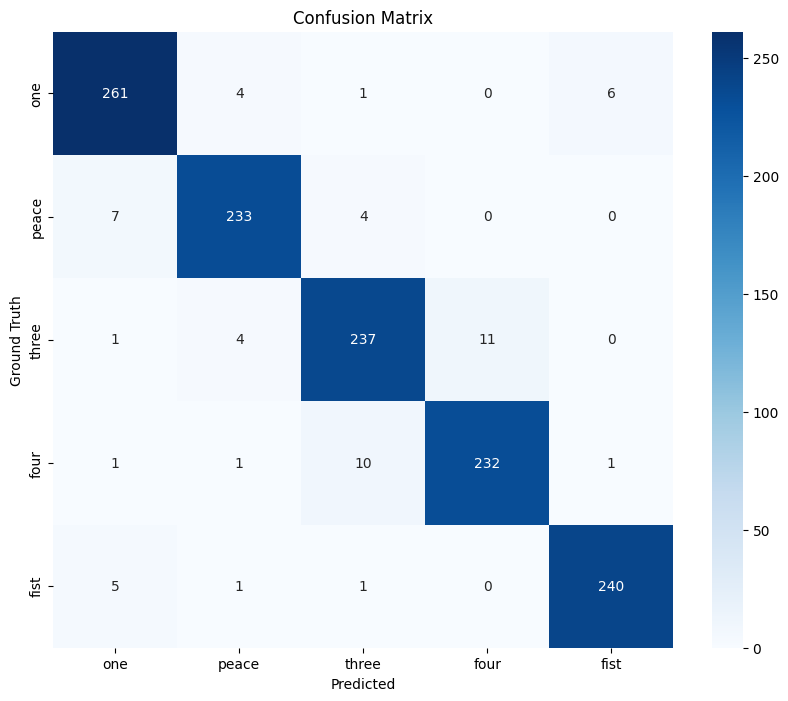

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

@torch.no_grad()
def final_report(model, loader):
    model.eval()
    gt_labels, pred_labels = [], []
    for batch in tqdm(loader):
        x = batch["image"].to(device)
        box_preds, cls_logits = model(x)
        p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)
        g_l = batch["target_label"].cpu().tolist()
        gt_labels.extend(g_l)
        pred_labels.extend(p_l)

    print("\n--- Classification Report ---")
    print(classification_report(gt_labels, pred_labels, target_names=TARGET_CLASSES))

    cm = confusion_matrix(gt_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Confusion Matrix')
    plt.show()

if 'clean_model' in globals():
    final_report(clean_model, test_loader)
else:
    print("Model not trained yet.")

Saved splits to: /kaggle/working/models/resnet18_splits.json
Saved environment info to: /kaggle/working/models/resnet18_env_info.txt


  0%|          | 0/40 [00:00<?, ?it/s]

Saved classification report to: /kaggle/working/models/resnet18_classification_report.json


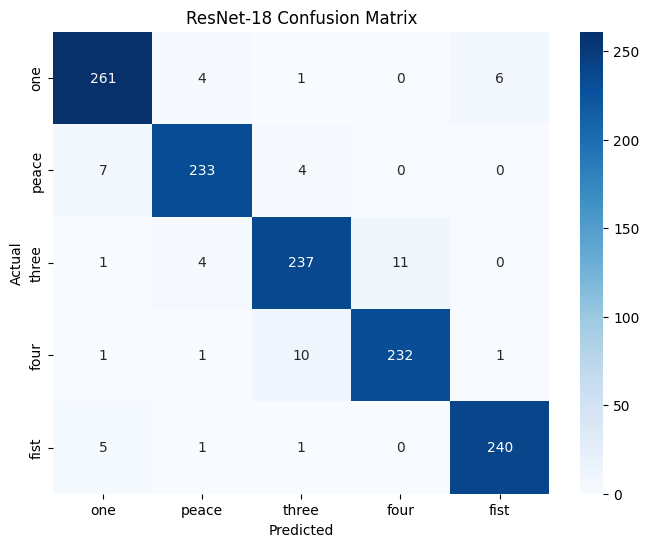

Saved confusion matrix image to: /kaggle/working/models/resnet18_confusion_matrix.png
Saved training history to: /kaggle/working/models/resnet18_training_history.csv
Saved report summary to: /kaggle/working/models/resnet18_report_summary.json


In [17]:
# Save split indices, environment details, and evaluation artifacts
import json, platform, subprocess, sys
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

REPORT_DIR = MODEL_DIR
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Persist train/val/test splits
splits = {
    'train': [r['image_path'] for r in train_records],
    'val': [r['image_path'] for r in val_records],
    'test': [r['image_path'] for r in test_records],
}
with open(REPORT_DIR / 'resnet18_splits.json', 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2)
print(f"Saved splits to: {REPORT_DIR / 'resnet18_splits.json'}")

# 2) Record environment details and pinned package snapshot
env_info = {
    'python': sys.version,
    'platform': platform.platform(),
    'torch': torch.__version__,
}
try:
    pip_freeze = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], stderr=subprocess.DEVNULL).decode('utf-8')
    env_info['pip_freeze'] = pip_freeze
except Exception as e:
    env_info['pip_freeze'] = f'pip freeze failed: {e}'

with open(REPORT_DIR / 'resnet18_env_info.txt', 'w', encoding='utf-8') as f:
    for k, v in env_info.items():
        if k == 'pip_freeze':
            f.write('\n== pip freeze ==\n')
            f.write(v)
        else:
            f.write(f"{k}: {v}\n")
print(f"Saved environment info to: {REPORT_DIR / 'resnet18_env_info.txt'}")

# 3) Save classification report + confusion matrix from test predictions
if 'clean_model' in globals() and 'test_loader' in globals():
    clean_model.eval()
    all_preds, all_gts = [], []
    for batch in tqdm(test_loader, leave=False):
        x = batch['image'].to(device)
        box_preds, cls_logits = clean_model(x)
        p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)
        all_preds.extend(p_l)
        all_gts.extend(batch["target_label"].cpu().tolist())

    clf_report = classification_report(all_gts, all_preds, target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
    with open(REPORT_DIR / 'resnet18_classification_report.json', 'w', encoding='utf-8') as f:
        json.dump(clf_report, f, indent=2)
    print(f"Saved classification report to: {REPORT_DIR / 'resnet18_classification_report.json'}")

    cm = confusion_matrix(all_gts, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('ResNet-18 Confusion Matrix')
    cm_path = REPORT_DIR / 'resnet18_confusion_matrix.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved confusion matrix image to: {cm_path}")

    if 'history_df' in globals():
        history_csv = REPORT_DIR / 'resnet18_training_history.csv'
        history_df.to_csv(history_csv, index=False)
        print(f"Saved training history to: {history_csv}")

    summary = {
        'best_model_path': str(MODEL_PATH) if 'MODEL_PATH' in globals() else str(REPORT_DIR / 'resnet18_hagrid_detector.pt'),
        'model_exists': (MODEL_PATH.exists() if 'MODEL_PATH' in globals() else (REPORT_DIR / 'resnet18_hagrid_detector.pt').exists()),
        'splits_file': str(REPORT_DIR / 'resnet18_splits.json'),
        'env_info_file': str(REPORT_DIR / 'resnet18_env_info.txt'),
        'classification_report': str(REPORT_DIR / 'resnet18_classification_report.json'),
        'confusion_matrix': str(REPORT_DIR / 'resnet18_confusion_matrix.png'),
    }
    with open(REPORT_DIR / 'resnet18_report_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    print(f"Saved report summary to: {REPORT_DIR / 'resnet18_report_summary.json'}")
else:
    print('Model or test_loader not available in the notebook state; run training and evaluation cells first.')


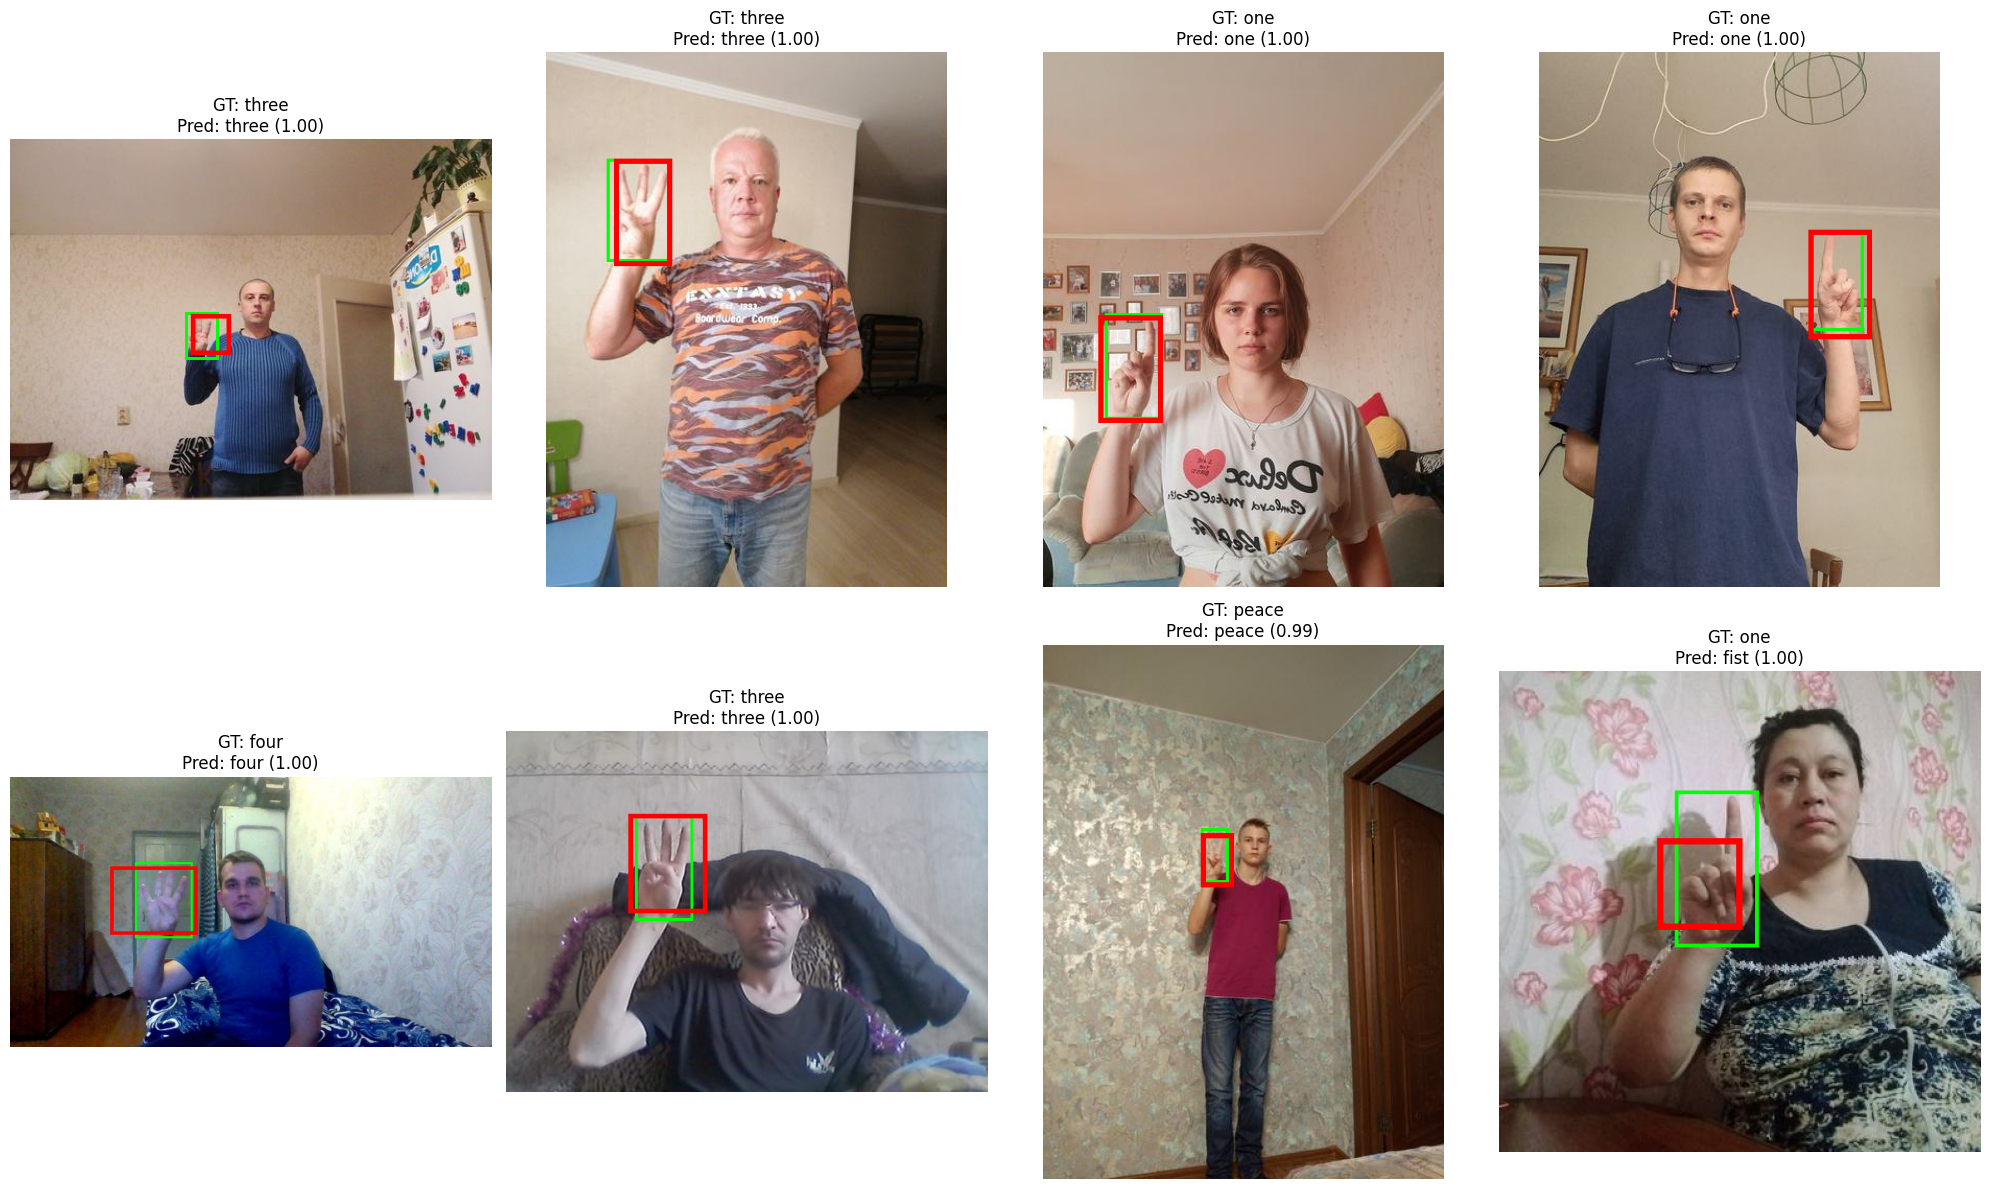

In [18]:
@torch.no_grad()
def visualize_predictions(model, dataset, n_show=8, score_thr=0.1, iou_thr=0.4):
    if len(dataset) == 0:
        print("Dataset empty")
        return

    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_show, len(dataset)), replace=False)
    plt.figure(figsize=(20, 12))

    for i, idx in enumerate(idxs, 1):
        sample = dataset.records[idx]
        with Image.open(sample["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size

            # Prep input
            resized = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
            x = np.asarray(resized, dtype=np.float32) / 255.0
            xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

            # Inference
            box_preds, cls_logits = model(xt)
            p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)

            # Draw Ground Truth (Green)
            gx1, gy1, gx2, gy2 = map(int, sample["bbox_xyxy"])
            draw_box(img, (gx1, gy1, gx2, gy2), color=(0, 255, 0), width=3)

            pred_text = "No Detection"
            if len(p_b) > 0:
                box = p_b[0].cpu().numpy()
                score = p_s[0]
                label = p_l[0]

                # RESCALE TO PIXELS
                px1, py1 = int(box[0] * w), int(box[1] * h)
                px2, py2 = int(box[2] * w), int(box[3] * h)

                draw_box(img, (px1, py1, px2, py2), color=(255, 0, 0), width=5)
                pred_text = f"Pred: {ID_TO_CLASS[label]} ({score:.2f})"

            plt.subplot((n_show + 3) // 4, 4, i)
            plt.imshow(img)
            plt.title(f"GT: {ID_TO_CLASS[sample['class_id']]}\n{pred_text}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Re-running visualization with red prediction boxes
visualize_predictions(clean_model, test_ds, n_show=8)

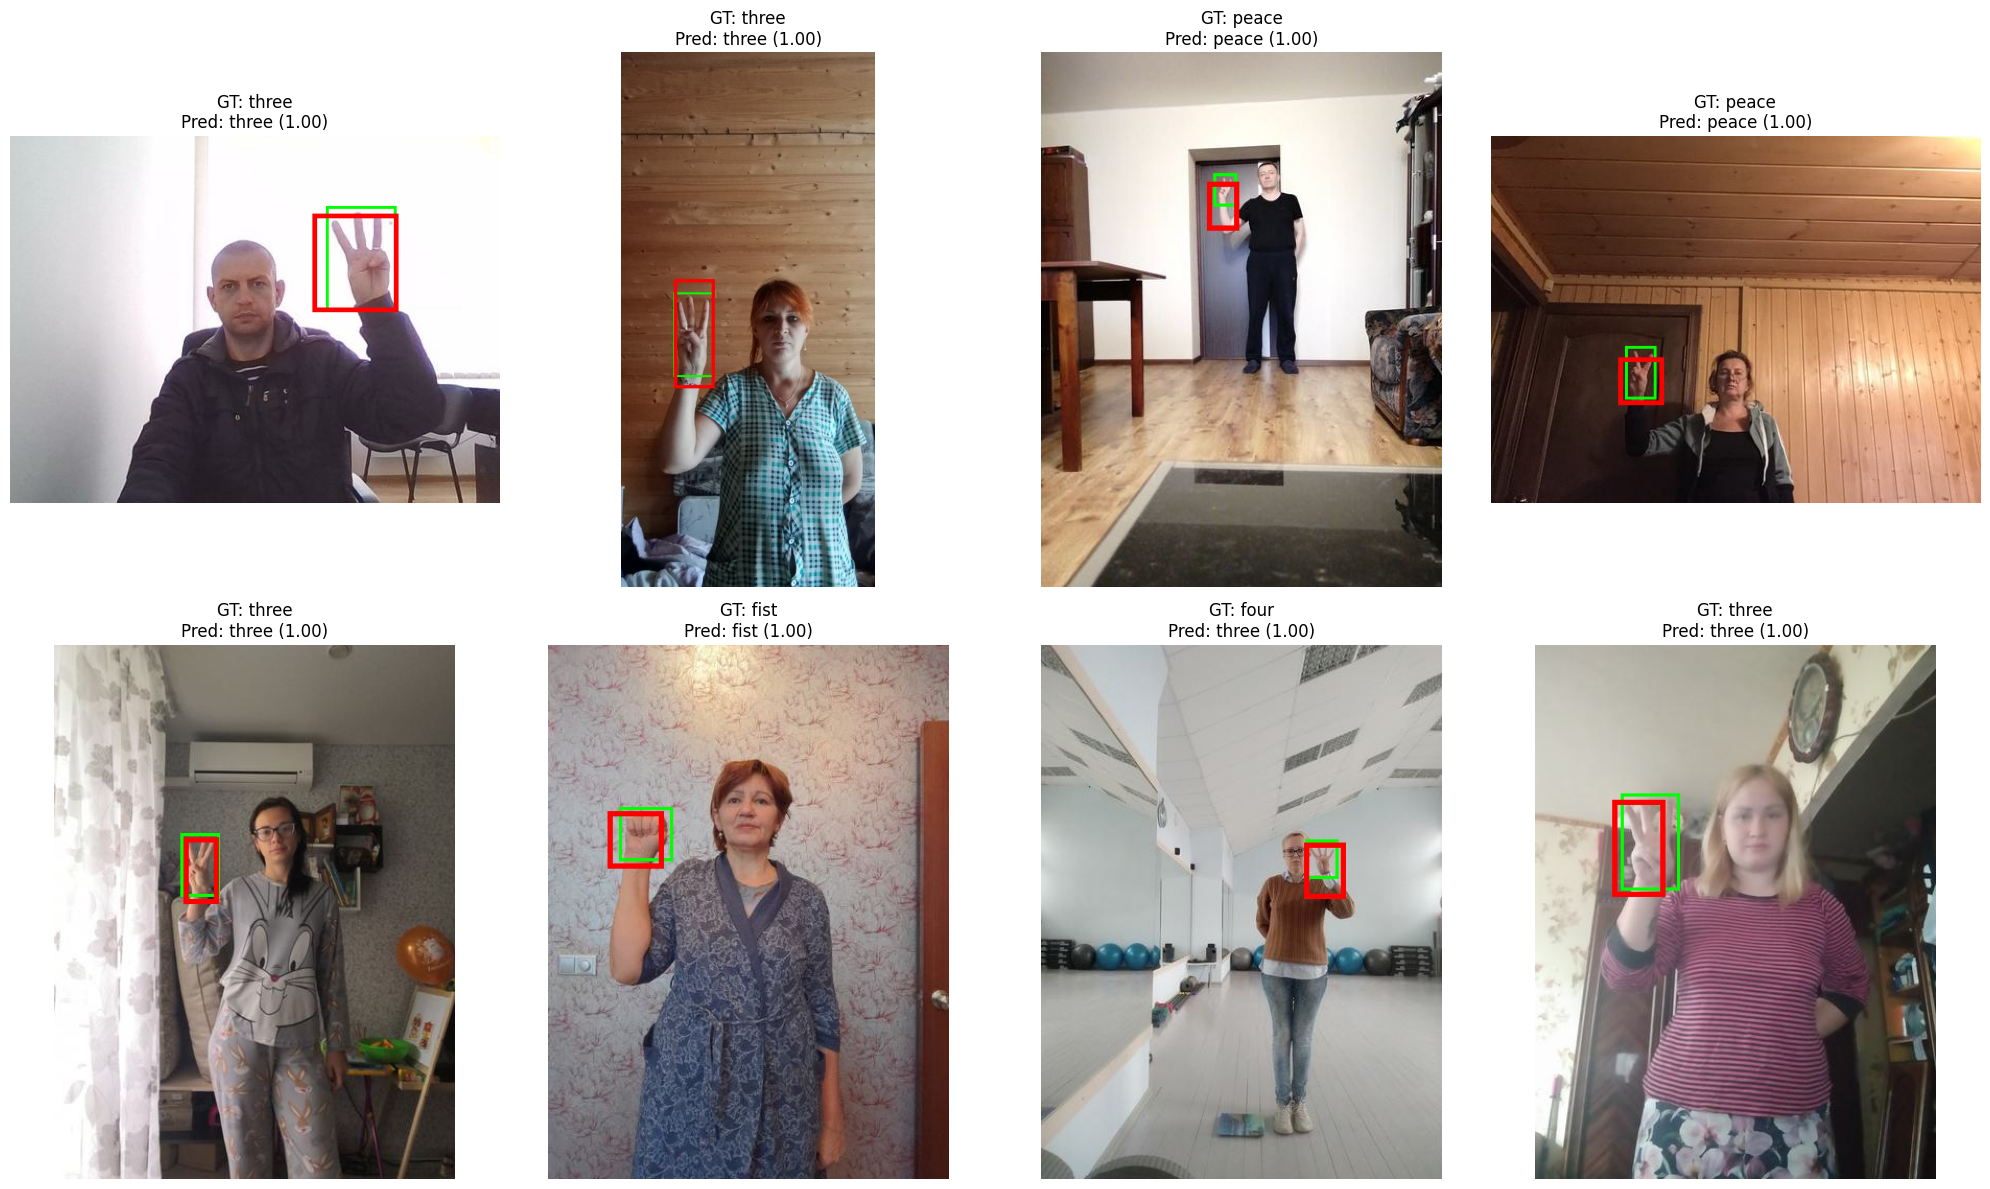

In [19]:
# Re-running visualization with red prediction boxes and score threshold 0.3
visualize_predictions(clean_model, test_ds, n_show=8, score_thr=0.3)


In [20]:
# Evaluate the model on the test set
print("Evaluating ResNet model on test data...")
test_metrics = evaluate_model(clean_model, test_loader)

# Display metrics nicely
metrics_df = pd.DataFrame([test_metrics])
display(metrics_df)


Evaluating ResNet model on test data...


,mAP50,mean_iou,latency_mean_ms
0,0.724361,0.619697,1.597797


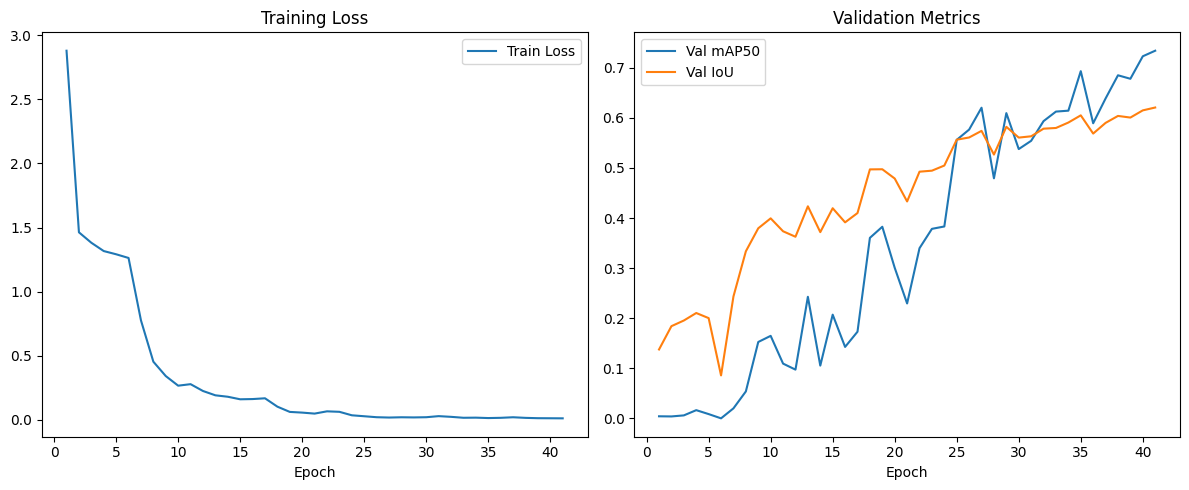

In [21]:
def plot_history(df):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df.get('mAP50', df.get('accuracy')), label='Val mAP50')
    plt.plot(df['epoch'], df['mean_iou'], label='Val IoU')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history_df' in globals():
    plot_history(history_df)
else:
    print("History not found. Ensure the training cell was executed.")


### Using the Trained Model for Inference

Here's how you can load your trained model and use it to make predictions on new images. You would typically do this in a separate script or when deploying your model.


## Plot training curves
Use the shared plotting helpers to view loss and accuracy.


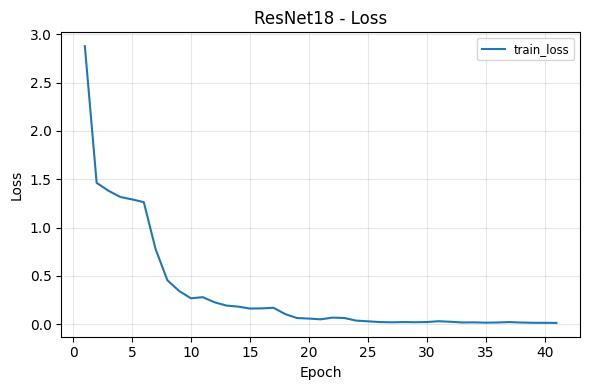

/tmp/ipykernel_23/3528358047.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small')


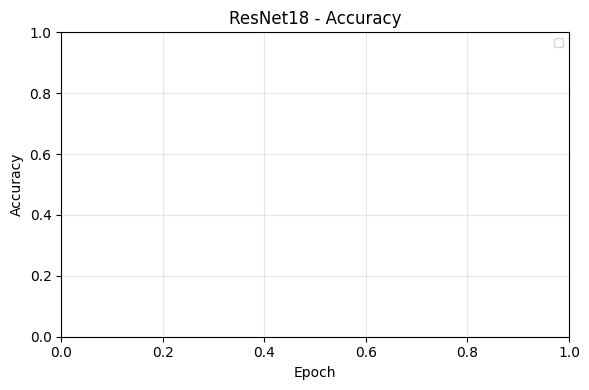

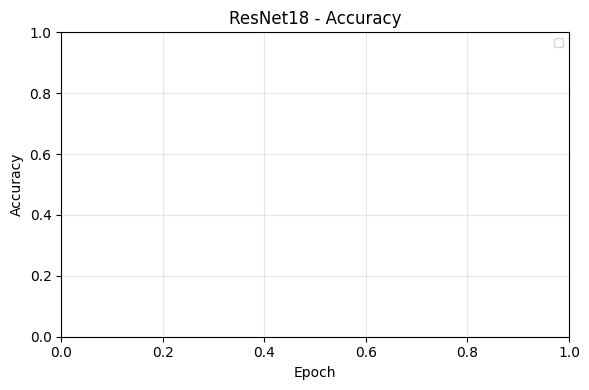

In [22]:
import pandas as pd
import matplotlib.pyplot as plt


def _load_history(source):
    if isinstance(source, pd.DataFrame):
        return source.copy()
    return pd.read_csv(source)


def _ensure_epochs(df):
    if 'epoch' in df.columns:
        return df
    df = df.reset_index().rename(columns={'index': 'epoch'})
    df['epoch'] = df['epoch'] + 1
    return df


def plot_loss_curve(source, title='Loss curves', ax=None):
    df = _ensure_epochs(_load_history(source))
    train_loss_cols = [c for c in df.columns if 'train' in c.lower() and 'loss' in c.lower()]
    val_loss_cols = [c for c in df.columns if ('val' in c.lower() or 'validation' in c.lower()) and 'loss' in c.lower()]

    if not train_loss_cols and 'loss' in df.columns:
        train_loss_cols = ['loss']
    if not val_loss_cols:
        val_loss_cols = [c for c in df.columns if 'val' in c.lower() and 'loss' in c.lower()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    for c in train_loss_cols:
        ax.plot(df['epoch'], df[c], label=c)
    for c in val_loss_cols:
        ax.plot(df['epoch'], df[c], '--', label=c)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize='small')
    plt.tight_layout()
    plt.show()
    return fig


def plot_accuracy_curve(source, title='Accuracy curves', ax=None):
    df = _ensure_epochs(_load_history(source))
    acc_cols = [c for c in df.columns if 'acc' in c.lower() or 'accuracy' in c.lower()]
    val_cols = [c for c in acc_cols if 'val' in c.lower() or 'validation' in c.lower()]
    train_cols = [c for c in acc_cols if c not in val_cols]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    for c in val_cols:
        ax.plot(df['epoch'], df[c], label=c)
    for c in train_cols:
        ax.plot(df['epoch'], df[c], '--', label=c)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize='small')
    plt.tight_layout()
    plt.show()
    return fig


history_csv = '/kaggle/working/models/resnet18_training_history.csv'
plot_loss_curve(history_csv, title='ResNet18 - Loss')
plot_accuracy_curve(history_csv, title='ResNet18 - Accuracy')
